# Import libraries

In [1]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [2]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [3]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def Friedmann_eq2(z, theta):
    omega_k, omega_DE, H0, w = theta
    omega_M = 1 - omega_k - omega_DE
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k, omega_DE, H0, w = theta
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    if not np.all(dl>0):
        print(f"luminosity distance isn't positive, {dl}, {s_k}, {rc}, {theta}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

In [4]:
#different equations of state:

"""w = w0 #wCDM
w = w0 + wa*(1+z)"""


'w = w0 #wCDM\nw = w0 + wa*(1+z)'

# Load the data

In [5]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [6]:
H0_prior = 73.3
H0_stdev_prior = 1.04
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056

def log_prior(theta, z):
    omega_k, omega_DE, H0, w = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-1<omega_k<1 and np.all(H2>0) and -3<w<-0.01 and 20<H0<100):
        return -np.inf
    return -0.5*(omega_DE-omega_DE_prior)**2/omega_DE_stdev_prior**2

nparams = 4
nwalkers = 50
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.6, 0.75)
    pos[i][2] = np.random.uniform(20, 100)
    pos[i][3] = np.random.uniform(-3,-0.01)
    

# Likelihood function

In [7]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [8]:
nsteps = 19000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 19000/19000 [30:51<00:00, 10.26it/s]


State([[ 1.04404057e-01  6.72776443e-01  8.17467044e+01 -7.09196026e-01]
 [-3.82759334e-02  6.97377549e-01  7.01633106e+01 -9.52710881e-01]
 [-6.50972188e-03  6.83980884e-01  7.20194668e+01 -8.45248196e-01]
 [ 5.34170952e-02  6.92721301e-01  7.65229454e+01 -7.16242271e-01]
 [ 9.29630813e-02  7.02208820e-01  8.05270207e+01 -6.82528281e-01]
 [ 9.32031345e-02  6.75951603e-01  8.02777580e+01 -6.95698239e-01]
 [ 4.13659817e-02  6.76780421e-01  7.57315197e+01 -7.85566661e-01]
 [ 5.08734930e-02  6.86319511e-01  7.64401090e+01 -7.70084664e-01]
 [ 1.67444035e-01  6.86060209e-01  8.89128505e+01 -6.02071574e-01]
 [ 1.38991161e-01  6.86409147e-01  8.51403627e+01 -6.11371128e-01]
 [ 1.01354528e-01  6.81371804e-01  8.12399605e+01 -7.12039357e-01]
 [-5.46879136e-02  6.91011824e-01  6.90698385e+01 -1.00994672e+00]
 [-4.01879321e-02  6.95948216e-01  6.95339291e+01 -8.44631699e-01]
 [ 9.15954193e-03  6.78742806e-01  7.31798095e+01 -8.45447777e-01]
 [ 4.99671934e-02  6.87296024e-01  7.59876685e+01 -6.838

100%|██████████| 5000/5000 [06:45<00:00, 12.34it/s]


autocorrelation time is [420.80609092  90.52796342 442.35622624 367.14350839]


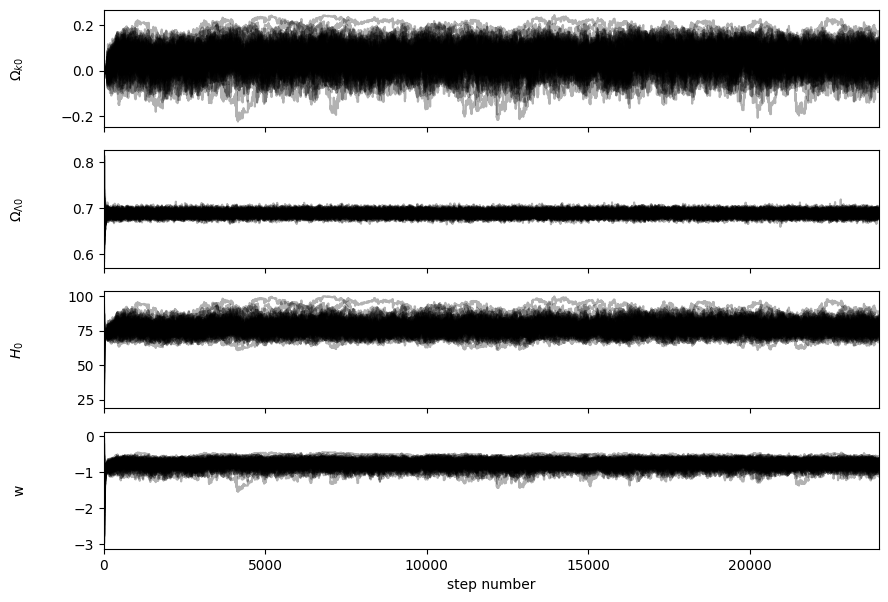

In [10]:
sampler.run_mcmc(None, 5000, progress = True)
ndiscard = 2000 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{Λ0}$", "$H_{0}$", "w"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers_wCDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

# Covariance plots

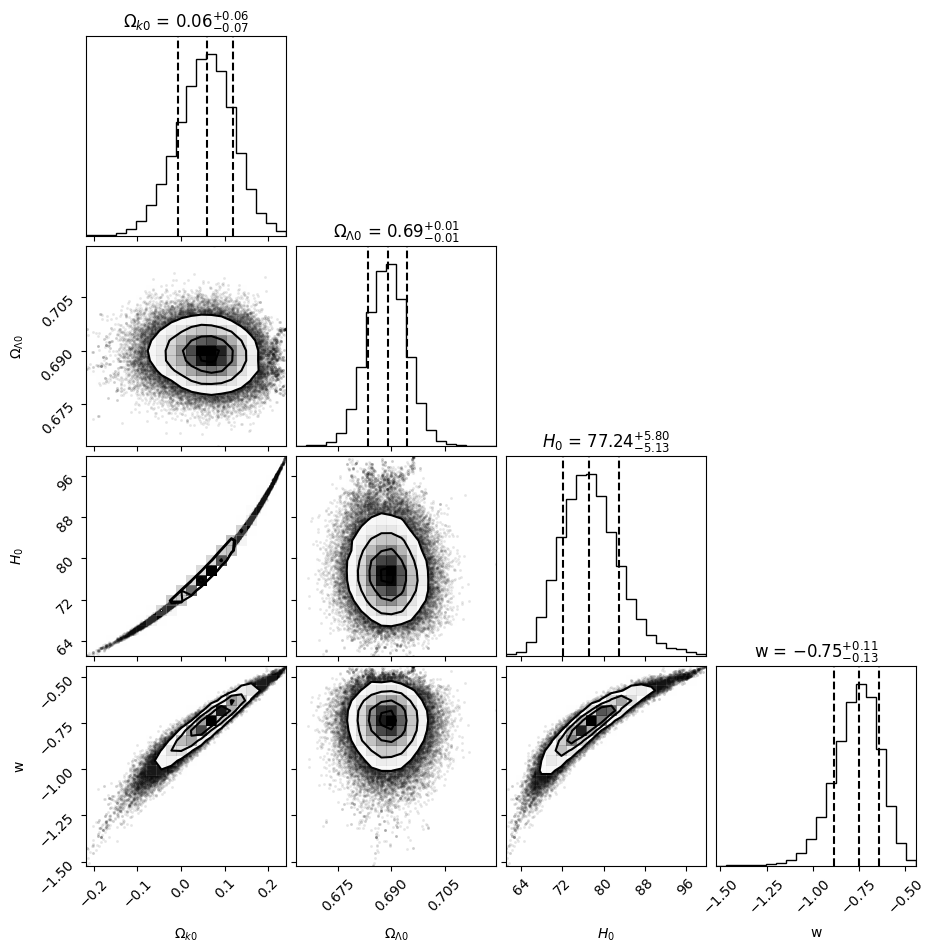

<Figure size 640x480 with 0 Axes>

In [16]:
#fig, axs = plt.subplots(4,4)
fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}
)
#axs[0,0].set_facecolor("lightblue")
plt.show()
#plt.suptitle('CORNER PLOT')
#plt.savefig('test_corner.png')
#plt.show()
plt.close()
plt.savefig("corner_wCDM.png")

In [62]:
with open("flat_samples_wCDM.txt", "a") as f:
    samples = sampler.get_chain(flat = True)
    for walkercoords in samples:
        f.write(str(walkercoords))
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: 0.06393404292857705 + 0.06005389751372235 - 0.06731259315111782
$Ω_{Λ0}$: 0.6855828675903028 + 0.016909754060264737 - 0.017052808209432224
$H_{0}$: 77.68083045677527 + 5.815970202512574 - 5.2841049704210405
w: -0.7498100281871105 + 0.11033251508313224 - 0.13127061953125818


In [14]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

chi-squared: 1748.555439451863


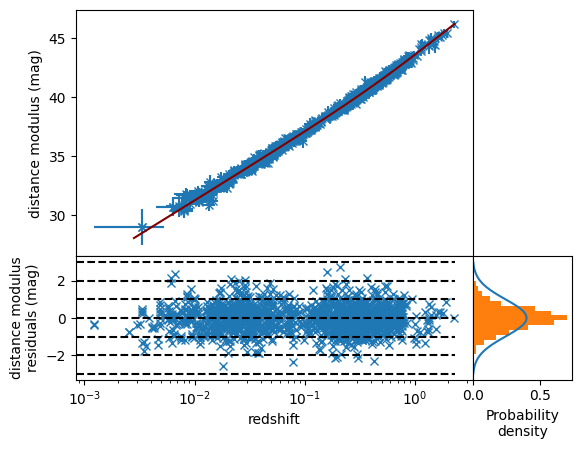

BIC: 1778.3113258214466


In [15]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 24))
plt.savefig("plot_wCDM", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")

AttributeError: 'Figure' object has no attribute 'plot'